<h1 style="text-align:center; color:#2E86C1;">
CNN Implementation on TensorFlow Datasets
</h1>

<h3 style="text-align:center;">
CIFAR-10 and Fashion MNIST Image Classification
</h3>

In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [4]:
classes = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

In [5]:
print(f"X_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


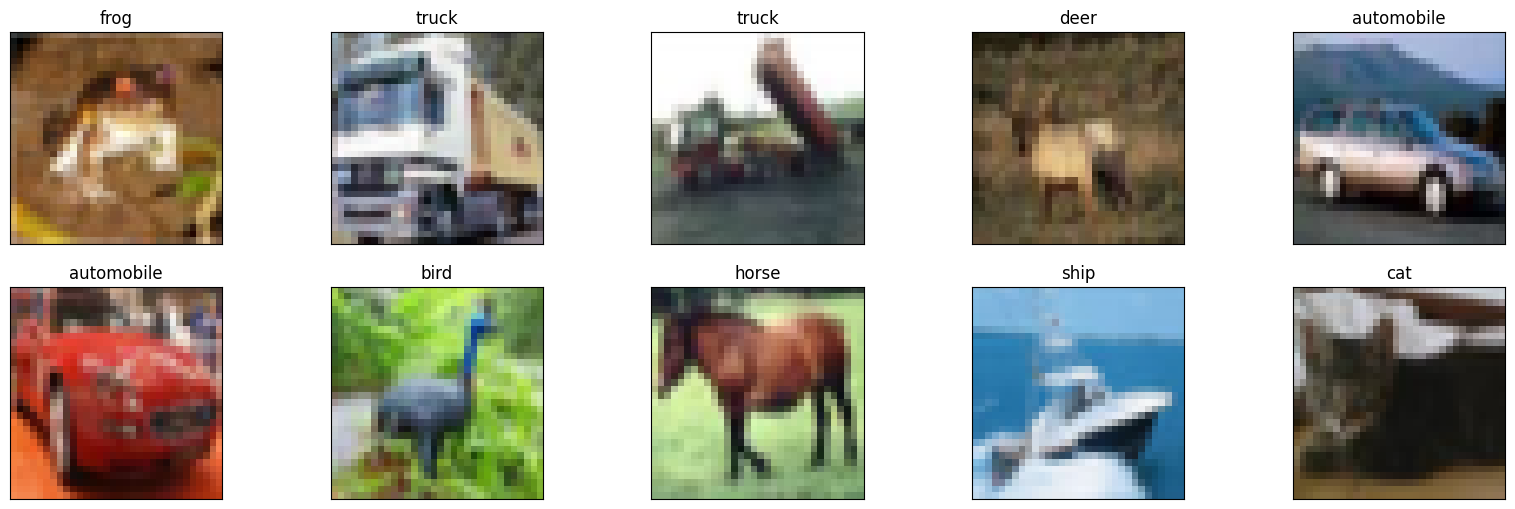

In [6]:
plt.figure(figsize = (20,16))
for i in range(10):
    plt.subplot(5,5, i+1)
    plt.imshow(x_train[i])
    plt.title(classes[y_train[i][0]])
    plt.xticks([])
    plt.yticks([])

In [16]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),   
    tf.keras.layers.BatchNormalization(),

    
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),   
    tf.keras.layers.BatchNormalization(),

    
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),  
    tf.keras.layers.BatchNormalization(),


    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),  
    tf.keras.layers.BatchNormalization(),


    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,586 (517.91 KB)

 Trainable params: 132,202 (516.41 KB)

 Non-trainable params: 384 (1.50 KB)

In [25]:
model_CNN = tf.keras.Sequential([
    tf.keras.Input(shape = (32,32,3)),
    data_augmentation,
    tf.keras.layers.Conv2D(32, 3, padding = 'same', activation='relu'),
    tf.keras.layers.Conv2D(32, 3, padding = 'same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    
    tf.keras.layers.Conv2D(64, 3, padding = 'same', activation='relu'),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    

    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dropout(0.3),
    

    tf.keras.layers.Dense(128, activation = 'relu'),

    tf.keras.layers.Dense(10, activation = 'softmax')
])

In [9]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [10]:
model_CNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1)
])

In [17]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
his = model.fit(x_train, y_train, batch_size = 64, epochs = 15, validation_data=(x_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.4283 - loss: 1.5893 - val_accuracy: 0.5328 - val_loss: 1.2676
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 58ms/step - accuracy: 0.5722 - loss: 1.1940 - val_accuracy: 0.4977 - val_loss: 1.4441
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.6289 - loss: 1.0433 - val_accuracy: 0.5988 - val_loss: 1.1447
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.6666 - loss: 0.9401 - val_accuracy: 0.5664 - val_loss: 1.2465
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.6908 - loss: 0.8723 - val_accuracy: 0.5676 - val_loss: 1.3813
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.7107 - loss: 0.8246 - val_accuracy: 0.6245 - val_loss: 1.0928
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.7229 - loss: 0.7858 - val_accuracy: 0.7179 - val_loss: 0.8284
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.7350 - loss: 0.7542 - 

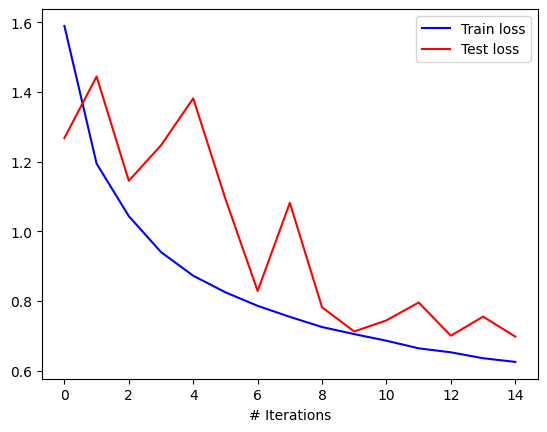

In [20]:
plt.plot(his.history['loss'],c='b',label='Train loss')
plt.plot(his.history['val_loss'],c='r',label='Test loss')
plt.xlabel('# Iterations')
plt.legend()

In [26]:
model_CNN.compile(optimizer = tf.keras.optimizers.Adagrad(), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
his2 = model_CNN.fit(x_train, y_train, batch_size = 64, epochs = 50, validation_data=(x_test, y_test))

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.1398 - loss: 2.2836 - val_accuracy: 0.1936 - val_loss: 2.2387
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.2076 - loss: 2.1734 - val_accuracy: 0.2817 - val_loss: 2.0307
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.2814 - loss: 1.9925 - val_accuracy: 0.3324 - val_loss: 1.8903
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.3232 - loss: 1.9003 - val_accuracy: 0.3640 - val_loss: 1.8133
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.3501 - loss: 1.8254 - val_accuracy: 0.3743 - val_loss: 1.7753
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.3748 - loss: 1.7596 - val_accuracy: 0.4090 - val_loss: 1.6697
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.3901 - loss: 1.7134 - val_accuracy: 0.4274 - val_loss: 1.6228
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.3986 - loss: 1.6796 - 

In [34]:
ypr = np.argmax(model.predict(x_test), axis = 1)
accuracy_score(y_test, ypr)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


0.7611

In [44]:
mask = ypr!=y_test.flatten()
x_test_mask = x_test[mask]
y_test_mask = y_test[mask]
ypr_mask = ypr[mask]

In [41]:
ypr

array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

In [43]:
y_test.flatten()

array([3, 8, 8, ..., 5, 1, 7], shape=(10000,), dtype=uint8)

In [45]:
y_test_mask

array([[5],
       [2],
       [4],
       ...,
       [5],
       [8],
       [3]], shape=(2389, 1), dtype=uint8)

<b>The model was unable to identify 2389 images out of 10000</b>

In [48]:
mask.sum()

np.int64(2389)

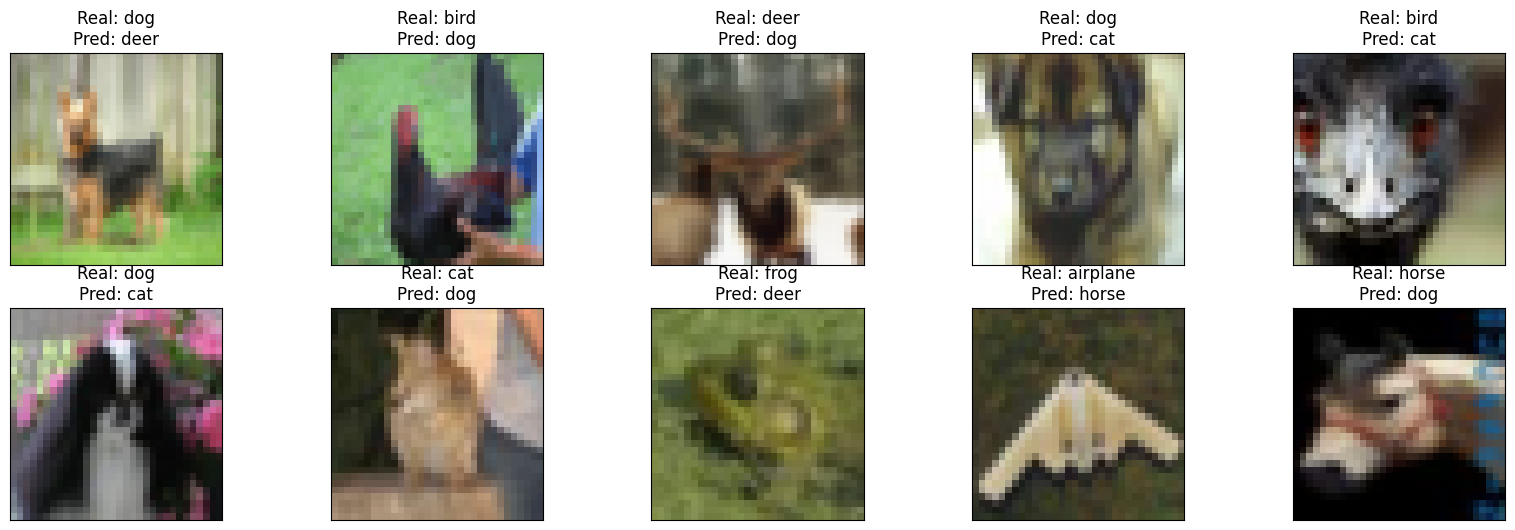

In [47]:
plt.figure(figsize = (20,16))
for i in range(10):
    plt.subplot(5,5, i+1)
    plt.imshow(x_test_mask[i])
    plt.title(f'Real: {classes[y_test_mask[i][0]]}\nPred: {classes[ypr_mask[i]]}')
    plt.xticks([])
    plt.yticks([])

In [49]:
from PIL import Image

In [74]:
def predict(img_path, k=5):
    img = Image.open(img_path)
    img = img.resize((32, 32))

    img = np.array(img).astype('float32') / 255.

    x = np.expand_dims(img, axis=0)

    ypred = model.predict(x, verbose=0)[0]

    plt.imshow(img)
    plt.title(f'Prediction: {classes[np.argmax(ypred)]}')
    plt.axis('off')
    plt.show()

    s = np.argsort(ypred)[::-1]

    for i in range(k):
        print(f'{classes[s[i]]}: {ypred[s[i]]:.4f}')
    

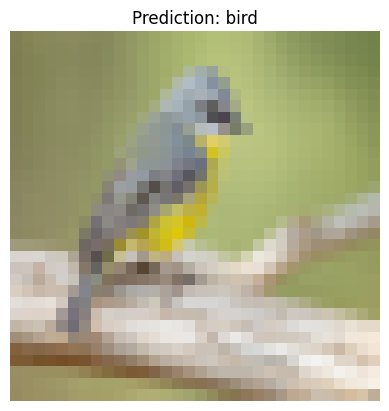

bird: 0.9799
frog: 0.0110
deer: 0.0038
dog: 0.0021
cat: 0.0019


In [75]:
predict('bird.jpg')

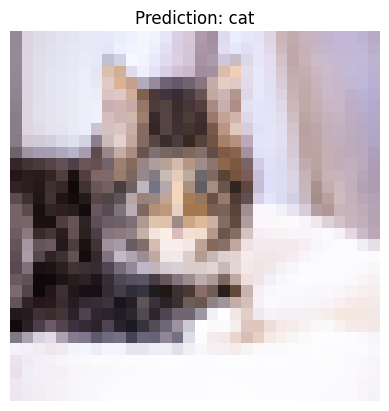

cat: 0.9492
dog: 0.0424
frog: 0.0046
horse: 0.0013
deer: 0.0012


In [76]:
predict('cat.jpg')

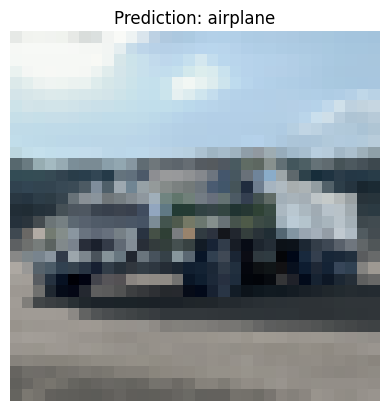

airplane: 0.5559
truck: 0.3097
automobile: 0.1281
ship: 0.0061
horse: 0.0001
cat: 0.0000
deer: 0.0000
bird: 0.0000
frog: 0.0000
dog: 0.0000


In [77]:
predict('truck.jpg',10)

In [120]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [121]:
classes = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [122]:
print(f"X_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [123]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

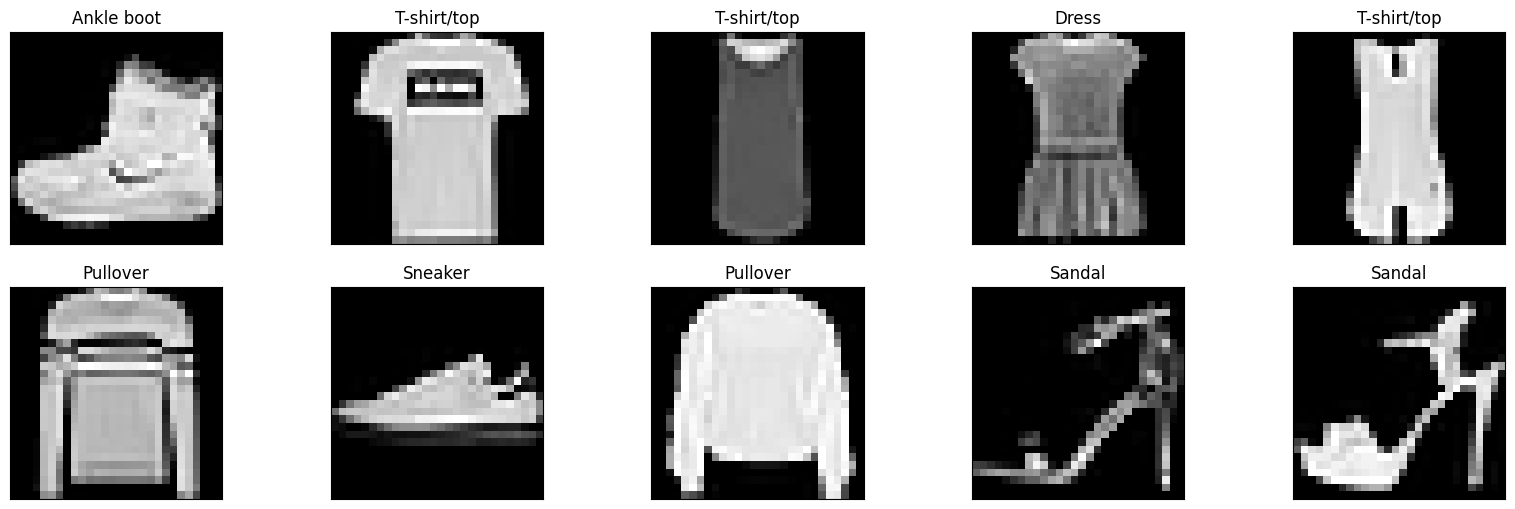

In [124]:
plt.figure(figsize = (20,16))
for i in range(10):
    plt.subplot(5,5, i+1)
    plt.imshow(x_train[i], cmap = 'gray')
    plt.title(classes[y_train[i]])
    plt.xticks([])
    plt.yticks([])

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [129]:
model_mnist =tf.keras.Sequential([
     tf.keras.Input(shape=(28,28, 1)),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),   
    tf.keras.layers.BatchNormalization(),

    
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),   
    tf.keras.layers.BatchNormalization(),

    
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),  
    tf.keras.layers.BatchNormalization(),


    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),  
    tf.keras.layers.BatchNormalization(),


    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,992 (1.51 MB)

 Trainable params: 132,202 (516.41 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 264,406 (1.01 MB)

In [132]:
model_mnist.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
his3 = model_mnist.fit(x_train, y_train, batch_size = 64, epochs = 10, validation_data=(x_test, y_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - accuracy: 0.8822 - loss: 0.3206 - val_accuracy: 0.8920 - val_loss: 0.2918
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.8964 - loss: 0.2812 - val_accuracy: 0.9035 - val_loss: 0.2664
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9028 - loss: 0.2623 - val_accuracy: 0.9034 - val_loss: 0.2619
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9079 - loss: 0.2466 - val_accuracy: 0.8991 - val_loss: 0.2729
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.9122 - loss: 0.2348 - val_accuracy: 0.9096 - val_loss: 0.2446
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9146 - loss: 0.2271 - val_accuracy: 0.9159 - val_loss: 0.2354
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9204 - loss: 0.2175 - val_accuracy: 0.9040 - val_loss: 0.2647
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9214 - loss: 0.2129 - 

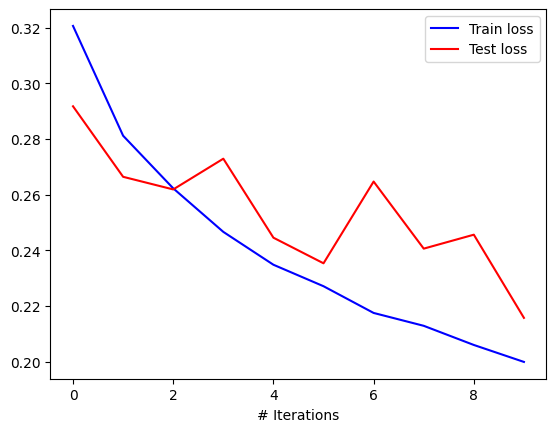

In [133]:
plt.plot(his3.history['loss'],c='b',label='Train loss')
plt.plot(his3.history['val_loss'],c='r',label='Test loss')
plt.xlabel('# Iterations')
plt.legend()

In [137]:
model_mnist.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[1.0797842e-08, 8.6716062e-10, 1.5216350e-10, ..., 1.1109028e-04,
        1.3545838e-10, 9.9988759e-01],
       [3.9749739e-05, 6.8332852e-08, 9.9929976e-01, ..., 2.1314543e-12,
        1.6300675e-09, 6.1417326e-15],
       [2.1207031e-08, 9.9999893e-01, 2.8678286e-08, ..., 1.3039965e-10,
        2.7655007e-09, 2.1894377e-11],
       ...,
       [2.1002031e-09, 3.0763933e-12, 1.2147089e-10, ..., 2.6868388e-11,
        1.0000000e+00, 4.3446070e-11],
       [6.8702150e-10, 1.0000000e+00, 6.0284649e-10, ..., 5.0365814e-12,
        4.0869708e-12, 7.1475852e-14],
       [3.5182945e-04, 1.0185499e-06, 6.9149651e-06, ..., 5.1080555e-01,
        2.2921166e-03, 6.1304990e-04]], shape=(10000, 10), dtype=float32)

In [138]:
ypr = np.argmax(model_mnist.predict(x_test), axis = 1)
accuracy_score(y_test, ypr)
mask = ypr!=y_test.flatten()
x_test_mask = x_test[mask]
y_test_mask = y_test[mask]
ypr_mask = ypr[mask]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [139]:
mask.sum()

np.int64(804)

<b>The model was unable to identify 804 images out of 10000</b>

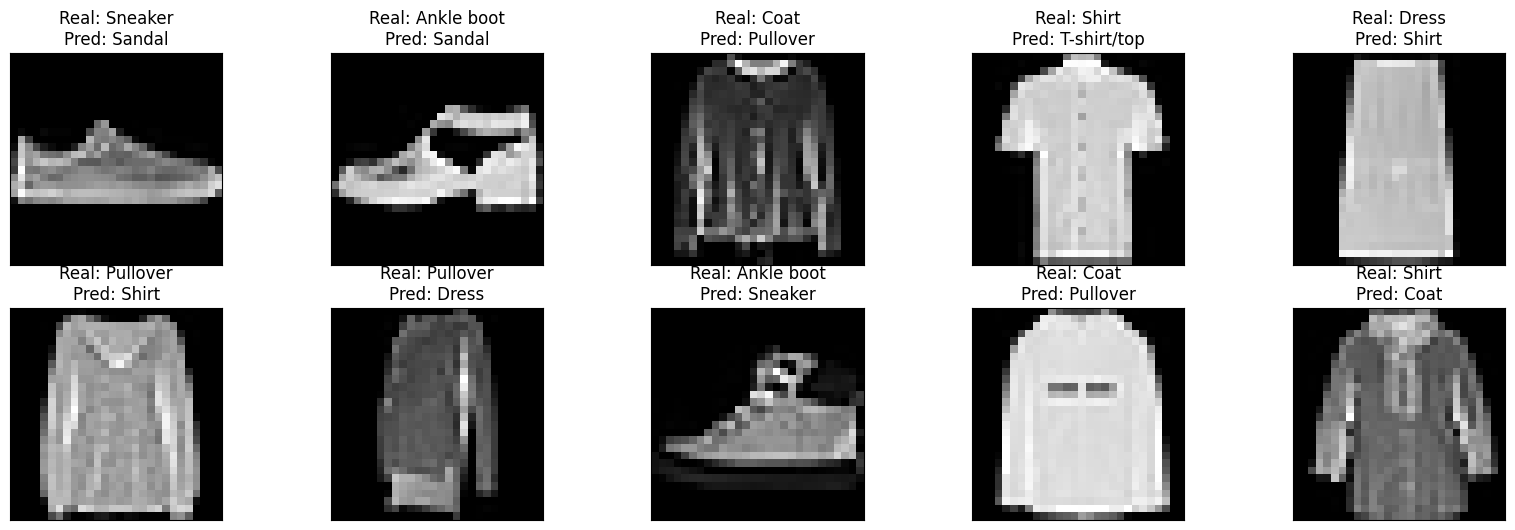

In [142]:
plt.figure(figsize = (20,16))
for i in range(10):
    plt.subplot(5,5, i+1)
    plt.imshow(x_test_mask[i], cmap = 'gray')
    plt.title(f'Real: {classes[y_test_mask[i]]}\nPred: {classes[ypr_mask[i]]}')
    plt.xticks([])
    plt.yticks([])

In [145]:
def Predict(img_path, k=5):
    img = Image.open(img_path)
    img = img.convert('L')
    img = img.resize((28, 28))
    img = np.array(img).astype('float32')
        
    x = np.expand_dims(img, axis=0)

    ypred = model_mnist.predict(x, verbose=0)[0]

    plt.imshow(img, cmap = 'gray')
    plt.title(f'Prediction: {classes[np.argmax(ypred)]}')
    plt.axis('off')
    plt.show()

    s = np.argsort(ypred)[::-1]

    for i in range(k):
        print(f'{classes[s[i]]}: {ypred[s[i]]:.4f}')

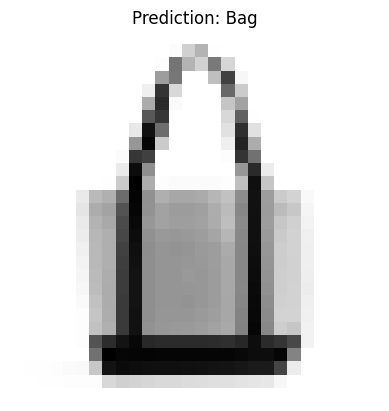

Bag: 0.9968
Ankle boot: 0.0015
T-shirt/top: 0.0010
Pullover: 0.0003
Shirt: 0.0002


In [146]:
Predict('bag.webp')

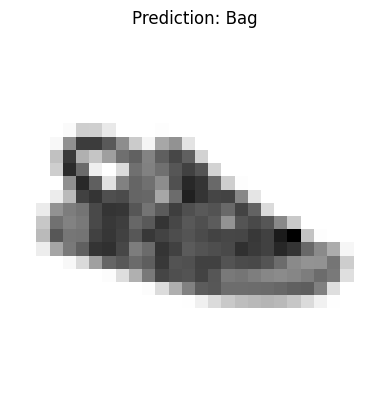

Bag: 1.0000
Ankle boot: 0.0000
T-shirt/top: 0.0000
Shirt: 0.0000
Pullover: 0.0000


In [148]:
Predict('sandal.jpg')

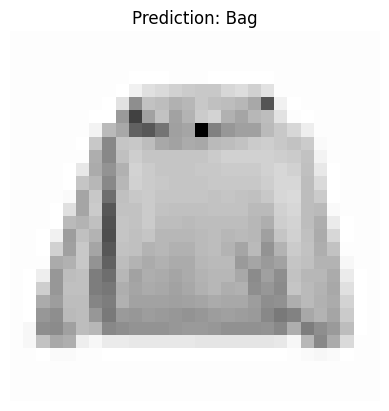

Bag: 0.9997
T-shirt/top: 0.0001
Shirt: 0.0001
Pullover: 0.0001
Ankle boot: 0.0000
Dress: 0.0000
Coat: 0.0000
Trouser: 0.0000
Sandal: 0.0000
Sneaker: 0.0000


In [153]:
Predict('pullover.avif',10)

In [156]:
accuracy_score(y_test,ypr)

0.9196